# 01 — Target definition и массовые метрики

Источник истины для detector success/failure. Target выбирается до атаки как самый уверенный clean `person`; success означает отсутствие matched target при `IoU >= 0.5` и `confidence >= 0.25`. Global winner и legacy confidence drop здесь только вторичные outcomes.

In [1]:
from pathlib import Path
import sys
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None: raise RuntimeError('Run from inside PatchSuccessResearch')
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.plots import plot_candidate_overview
from CandidateRoutingAndAttackPath.target_instance_metrics import (
    TargetInstanceConfig, build_target_instance_labels, evaluate_attack_path_metrics,
    evaluate_candidate_routing_metrics, image_key, load_target_labels,
    reevaluate_historical_detector_metrics,
)
pd.set_option('display.max_columns', 100); pd.set_option('display.max_rows', 100)
plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


In [2]:
OUTPUT_DIR = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'target_instance_all_metrics'
TRACE_DB = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
LEGACY_ATTACK_PATH_DB = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'attack_path_5ef23878fe1dfaea' / 'attack_path.sqlite'
LEGACY_QUALITY = REPO_ROOT / 'ClassifierDetectorExperiments' / 'outputs' / 'all_metrics_quality.csv'
MATCH_IOU, DETECTION_CONF, INFERENCE_CONF = 0.50, 0.25, 0.01
TARGET_SUPPRESSION_DELTA, BATCH_SIZE = 0.30, 16
FORCE_LABEL_REBUILD = False
FORCE_METRIC_REBUILD = False
display(pd.Series({
    'target': 'highest-confidence clean person',
    'match': f'IoU >= {MATCH_IOU}',
    'success': f'no matched target at confidence >= {DETECTION_CONF}',
    'legacy only': f'global max-person drop > {TARGET_SUPPRESSION_DELTA}',
}).to_frame('fixed definition'))

,fixed definition
target,highest-confidence clean person
match,IoU >= 0.5
success,no matched target at confidence >= 0.25
legacy only,global max-person drop > 0.3


In [3]:
exp, attack_cache_path = load_experiment(repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False)
cache = exp.get_cache()
label_config = TargetInstanceConfig(
    output_dir=str(OUTPUT_DIR), match_iou=MATCH_IOU, detection_conf=DETECTION_CONF,
    inference_conf=INFERENCE_CONF, target_suppression_delta=TARGET_SUPPRESSION_DELTA,
    batch_size=BATCH_SIZE, max_examples=None, progress=True,
)
target_result = build_target_instance_labels(exp, label_config, force=FORCE_LABEL_REBUILD)
labels = load_target_labels(target_result)
eligible = labels[labels.target_eligible.eq(1) & labels.target_hidden.notna()].copy()
eligible['primary_success'] = eligible.target_hidden.astype(bool)
eligible['legacy_success_bool'] = eligible.legacy_success.astype(bool)
print(target_result.digest_path.read_text())
print('labels:', target_result.labels_path)

target-instance labeling: 0img [00:00, ?img/s]

# Target-instance labels

- rows: 6000
- baseline-eligible targets: 5985
- primary target-hidden rate: 0.346
- legacy max-confidence success rate: 0.501
- legacy/target label agreement: 0.730

Primary success is target_hidden. legacy_success is retained only for comparison.

labels: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_instance_all_metrics/target_instance_bc9b647edb5cdec7/target_instance_labels.csv


## Label audit и outcomes

primary_success,target hidden,target visible,All
legacy_success_bool,,,
legacy fail,343,2642,2985
legacy success,1726,1274,3000
All,2069,3916,5985


,n
outcome,
target_visible_target_winner,3624
target_hidden_non_target_winner,2003
target_visible_non_target_winner,292
target_hidden_no_person,66


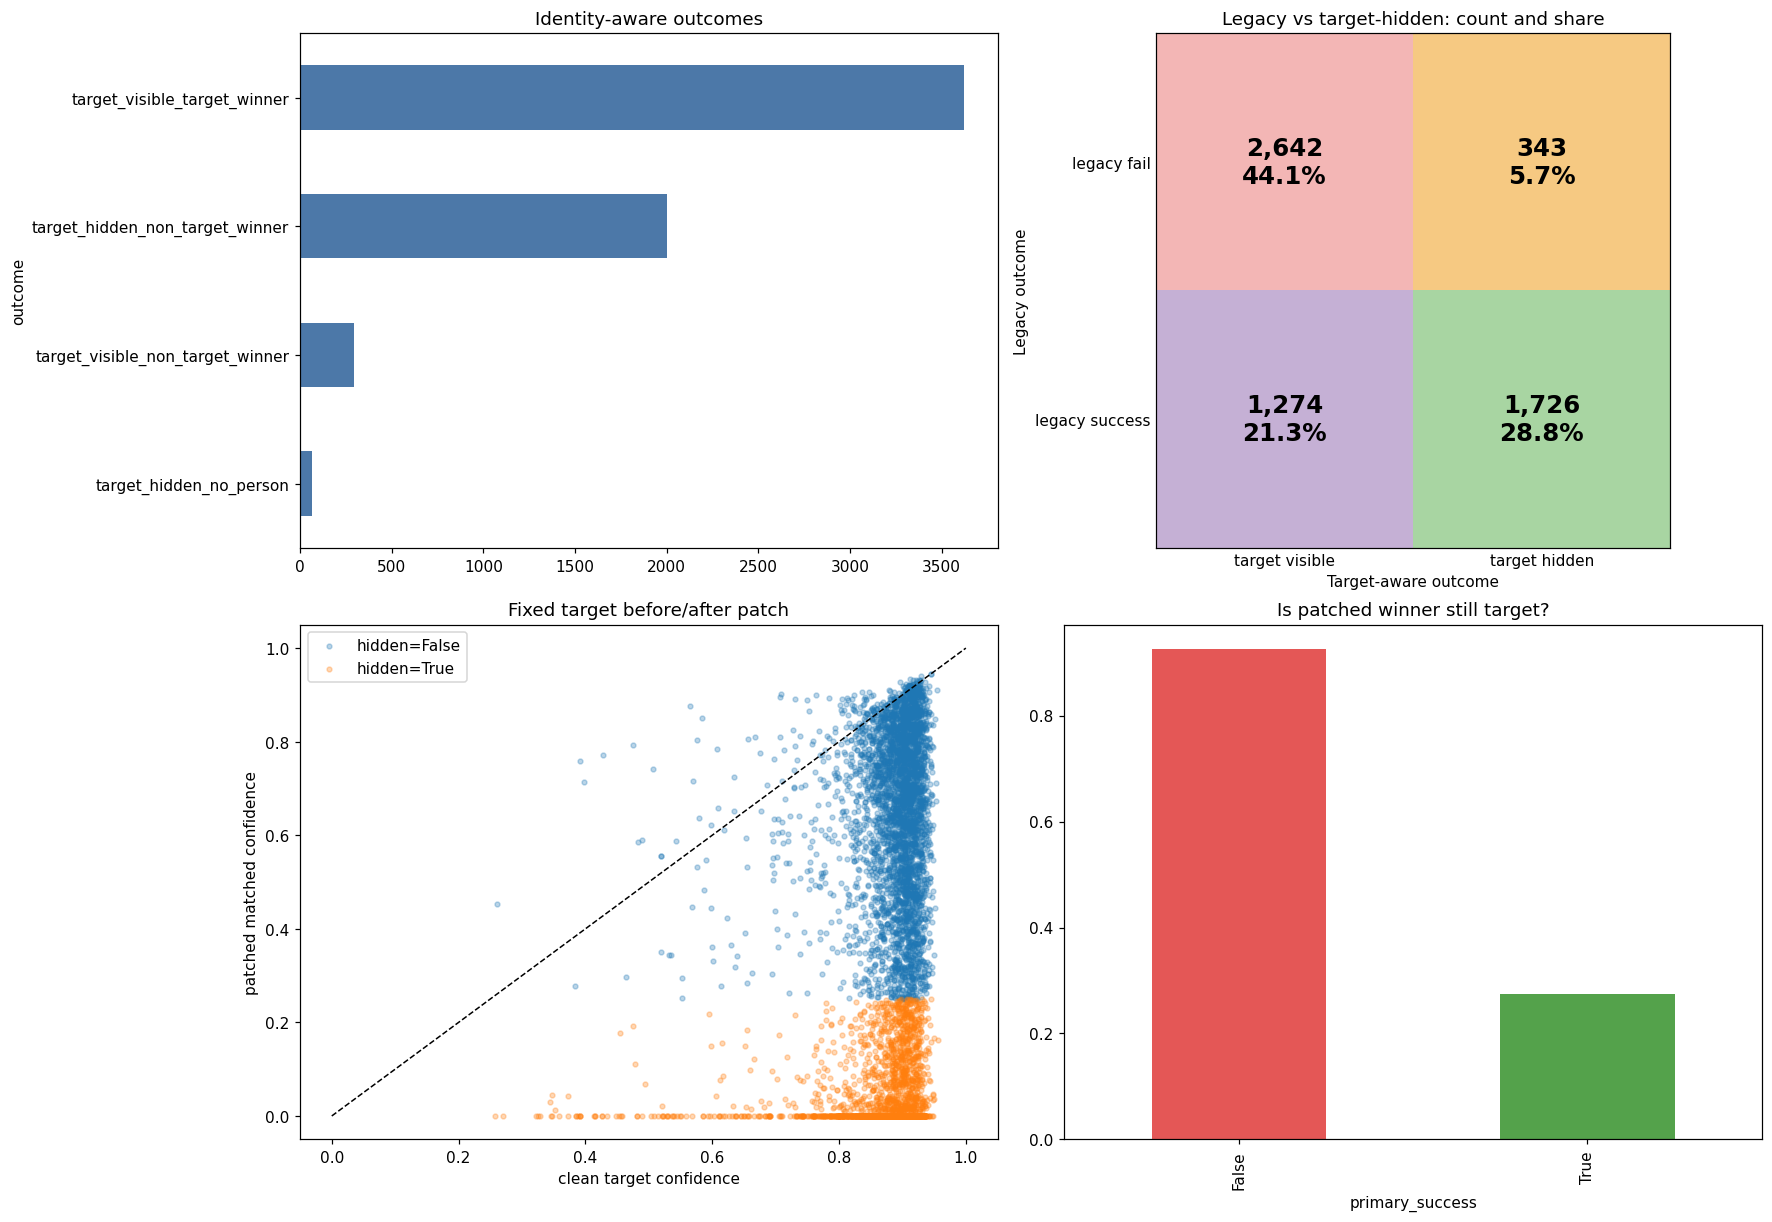

In [4]:
display(pd.crosstab(
    eligible.legacy_success_bool.map({False: 'legacy fail', True: 'legacy success'}),
    eligible.primary_success.map({False: 'target visible', True: 'target hidden'}), margins=True,
))
display(eligible.outcome.value_counts().rename_axis('outcome').to_frame('n'))
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
eligible.outcome.value_counts().sort_values().plot.barh(ax=axes[0, 0], color='#4c78a8', title='Identity-aware outcomes')
agreement = pd.crosstab(eligible.legacy_success_bool, eligible.primary_success).reindex(index=[False, True], columns=[False, True], fill_value=0)
tile_colors = np.array([[0, 1], [2, 3]])
from matplotlib.colors import ListedColormap
axes[0, 1].imshow(tile_colors, cmap=ListedColormap(['#f3b6b5', '#f6c982', '#c5b0d5', '#a8d5a2']), vmin=-0.5, vmax=3.5)
for row in range(2):
    for col in range(2):
        n = int(agreement.iloc[row, col])
        axes[0, 1].text(col, row, f'{n:,}\n{n / agreement.to_numpy().sum():.1%}', ha='center', va='center', fontsize=16, fontweight='bold')
axes[0, 1].set_xticks([0, 1], ['target visible', 'target hidden'])
axes[0, 1].set_yticks([0, 1], ['legacy fail', 'legacy success'])
axes[0, 1].set_xlabel('Target-aware outcome'); axes[0, 1].set_ylabel('Legacy outcome')
axes[0, 1].set_title('Legacy vs target-hidden: count and share')
axes[0, 1].tick_params(length=0)
for success, group in eligible.groupby('primary_success'):
    axes[1, 0].scatter(group.target_clean_conf, group.target_patched_conf, s=10, alpha=.3, label=f'hidden={success}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1); axes[1, 0].legend()
axes[1, 0].set(xlabel='clean target confidence', ylabel='patched matched confidence', title='Fixed target before/after patch')
eligible.groupby('primary_success').patched_winner_is_target.mean().plot.bar(ax=axes[1, 1], color=['#e45756', '#54a24b'], title='Is patched winner still target?')
plt.show()

**Что видно на графике.** Из 5 985 eligible-примеров чаще всего исходный человек остаётся видимым и остаётся winner (`3 624`). Скрытие почти всегда сопровождается передачей лидерства другому person-кандидату (`2 003`); полное отсутствие person-детекций встречается лишь в `66` случаях. Значит, основной наблюдаемый режим атаки — не уничтожение всех person-сигналов, а перестройка конкуренции кандидатов вокруг конкретного target.

Legacy- и target-aware разметки расходятся в `1 617 / 5 985 = 27.0%` случаев: `1 274` legacy-success на самом деле оставляют выбранного человека видимым, а `343` legacy-fail его скрывают. Это достаточно большая примесь, чтобы менять ранжирование метрик. Scatter показывает общее падение confidence после патча, но разделение цветов относительно порога `0.25` частично задано самой меткой и не является механистическим объяснением. Наконец, даже среди hidden-примеров исходная clean-ячейка остаётся patched winner примерно в четверти случаев: часть hiding возникает через падение confidence или сдвиг бокса, а не через обязательную замену winner.

,confidence threshold,eligible,hidden rate
0,0.150,5992,0.289887
1,0.175,5991,0.303622
2,0.200,5988,0.317134
3,0.225,5986,0.331273
4,0.250,5985,0.345698
5,0.275,5982,0.359244
6,0.300,5982,0.372952
7,0.325,5981,0.387895
8,0.350,5975,0.401004


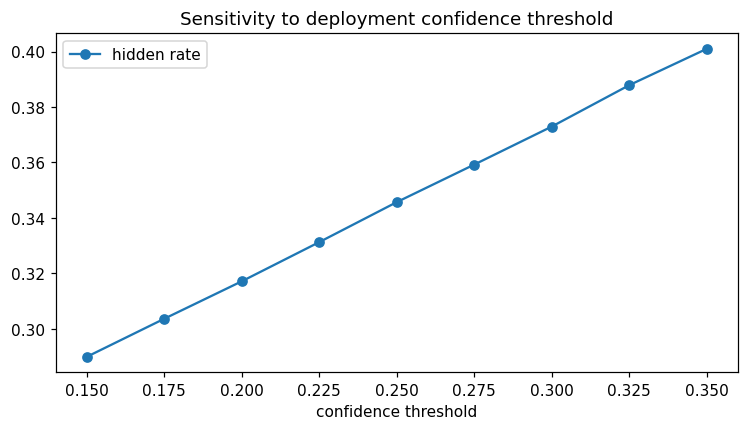

In [5]:
rows = []
for threshold in np.arange(.15, .36, .025):
    subset = labels[labels.target_clean_conf.ge(threshold)]
    hidden = subset.target_patched_conf.fillna(0).lt(threshold)
    rows.append({'confidence threshold': threshold, 'eligible': len(subset), 'hidden rate': hidden.mean()})
threshold_sweep = pd.DataFrame(rows)
display(threshold_sweep)
threshold_sweep.plot(x='confidence threshold', y='hidden rate', marker='o', figsize=(8, 4), title='Sensitivity to deployment confidence threshold')
plt.show()

**Что видно на графике.** При повышении deployment threshold с `0.15` до `0.35` hidden rate почти линейно растёт с `29.0%` до `40.1%`, тогда как размер eligible-выборки почти не меняется (`5 992 → 5 975`). Следовательно, около 11 процентных пунктов итогового ASR определяются выбранным рабочим порогом confidence, а не дискретным исчезновением детекции. Порог `0.25` — разумная фиксированная operating point, но результаты по success rate необходимо сопровождать threshold sweep или непрерывными confidence/IoU endpoint-метриками.

## Исторические activation-метрики под новой меткой

,cache_file,status,source_rows,matched_rows,matched_unique_images
0,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN
1,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN
2,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,23988.0,20088.0,1674.0
3,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN
4,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN
5,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,15992.0,13392.0,1674.0
6,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,1999.0,1674.0,1674.0
7,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN
8,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,5646.0,4717.0,4717.0
9,/Users/ashentide/PycharmProjects/PatchSuccessR...,missing_or_unsupported,NaN,NaN,NaN


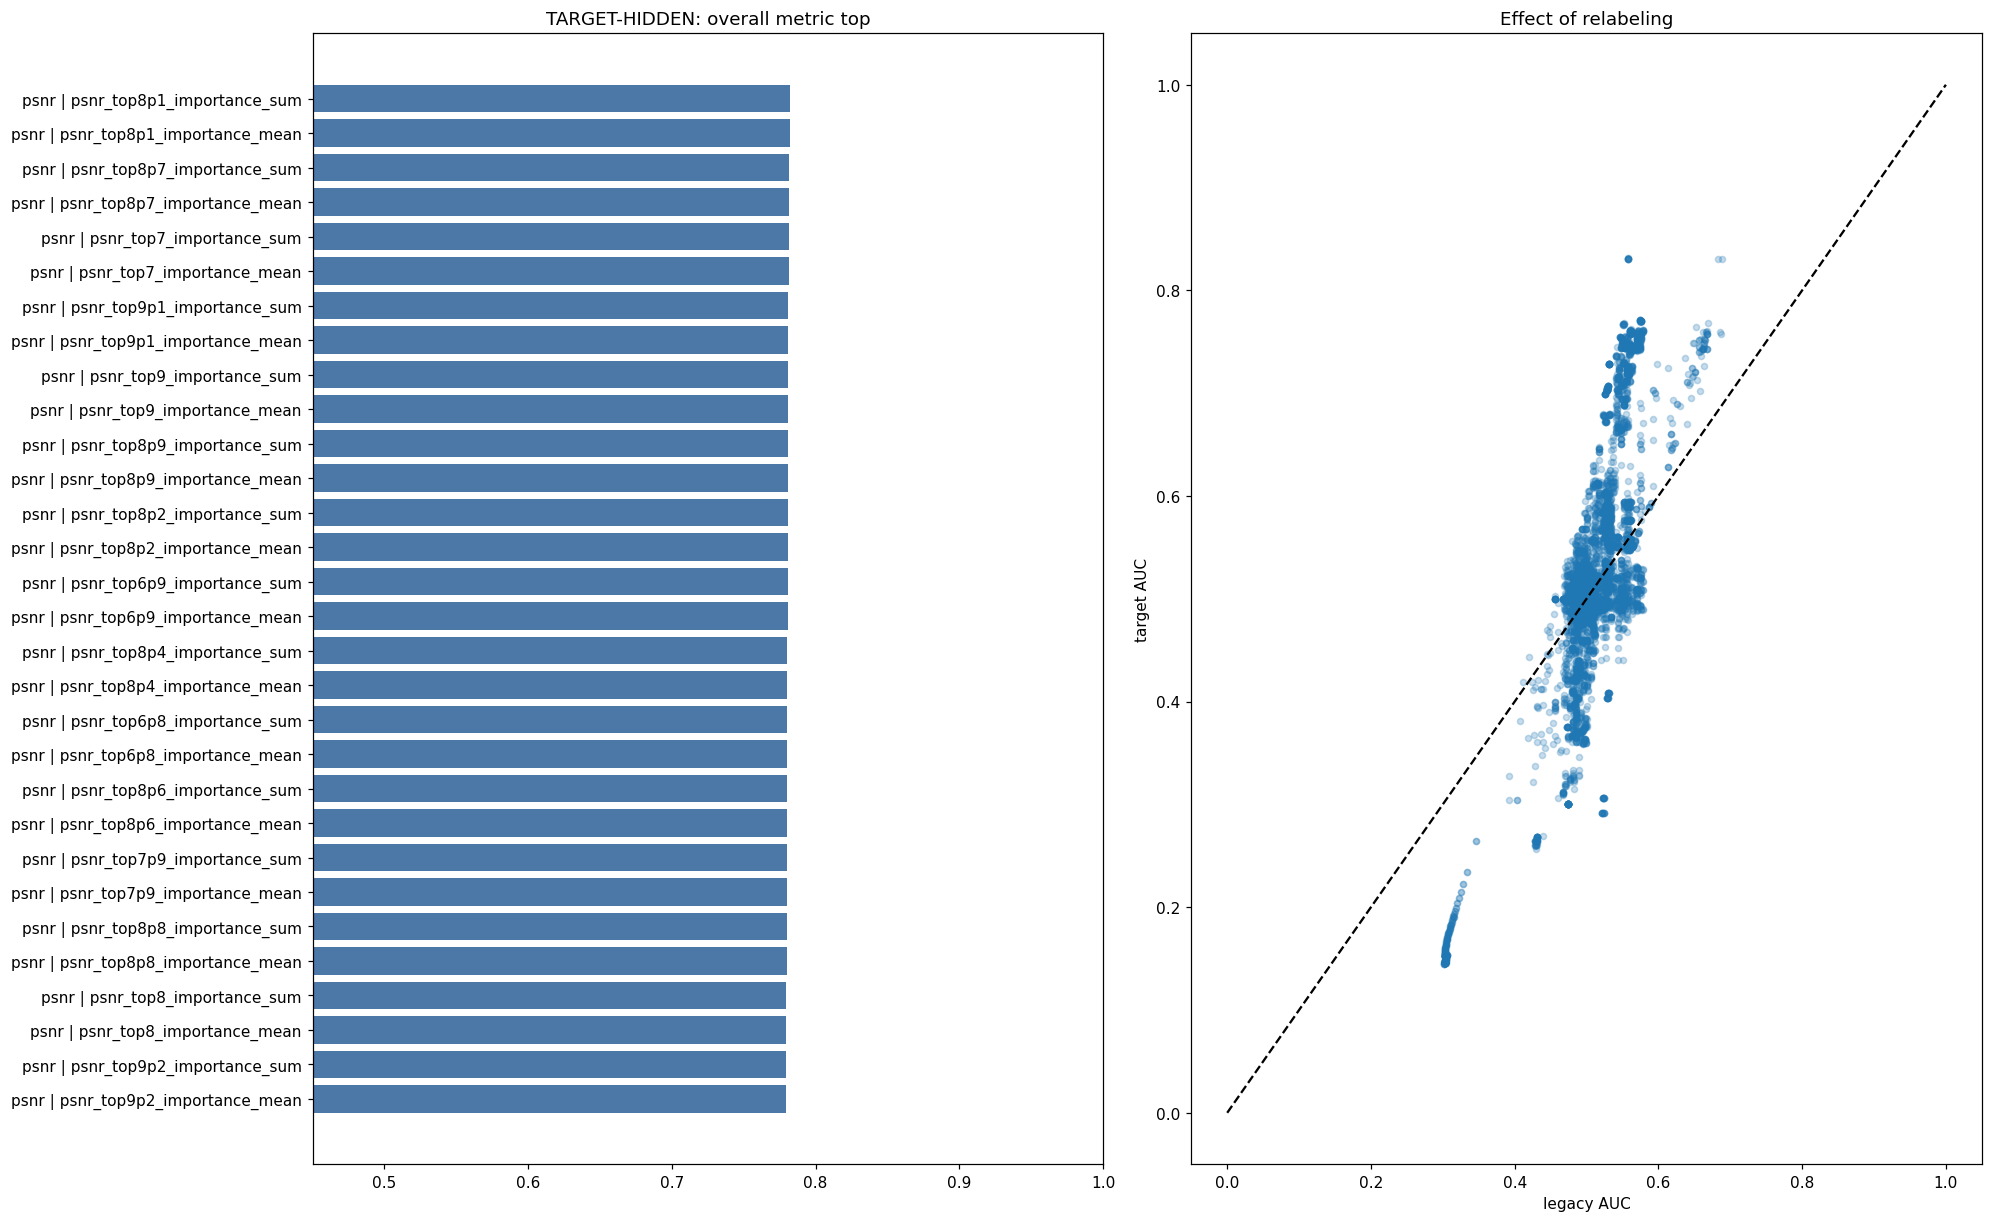

,source,experiment,metric,n,n_success,n_failure,roc_auc,cache_file,legacy_roc_auc,family,top_percent,aggregate,cov_method,sigma,cov_group,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction,effective_auc,label
0,detector_target_instance,psnr,psnr_top8p1_importance_sum,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,sum,NaN,NaN,NaN,0.687719,0.600920,0.803828,114687.157134,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,114687.157134,-1,0.854285,psnr | psnr_top8p1_importance_sum
1,detector_target_instance,psnr,psnr_top8p1_importance_mean,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,mean,NaN,NaN,NaN,0.687719,0.600920,0.803828,6.913446,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,6.913446,-1,0.854285,psnr | psnr_top8p1_importance_mean
2,detector_target_instance,psnr,psnr_top8p7_importance_sum,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,sum,NaN,NaN,NaN,0.687445,0.603199,0.799043,123412.498035,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,123412.498035,-1,0.855180,psnr | psnr_top8p7_importance_sum
3,detector_target_instance,psnr,psnr_top8p7_importance_mean,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,mean,NaN,NaN,NaN,0.687445,0.603199,0.799043,6.926282,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,6.926282,-1,0.855180,psnr | psnr_top8p7_importance_mean
4,detector_target_instance,psnr,psnr_top7_importance_sum,4717,1463,3254,0.147280,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303250,psnr_percent_sweep,7.0,sum,NaN,NaN,NaN,0.683495,0.575163,0.842105,99171.020210,-1,0.758109,0.781225,0.575163,0.842105,0.720344,0.683495,0.758109,99171.020210,-1,0.852720,psnr | psnr_top7_importance_sum
5,detector_target_instance,psnr,psnr_top7_importance_mean,4717,1463,3254,0.147280,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303250,psnr_percent_sweep,7.0,mean,NaN,NaN,NaN,0.683495,0.575163,0.842105,6.917621,-1,0.758109,0.781225,0.575163,0.842105,0.720344,0.683495,0.758109,6.917621,-1,0.852720,psnr | psnr_top7_importance_mean
6,detector_target_instance,psnr,psnr_top9p1_importance_sum,4717,1463,3254,0.148474,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303181,psnr_percent_sweep,9.1,sum,NaN,NaN,NaN,0.686030,0.596465,0.807245,128598.433896,-1,0.770829,0.781110,0.591472,0.815448,0.746773,0.685632,0.768073,128650.008285,-1,0.851526,psnr | psnr_top9p1_importance_sum
7,detector_target_instance,psnr,psnr_top9p1_importance_mean,4717,1463,3254,0.148474,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303181,psnr_percent_sweep,9.1,mean,NaN,NaN,NaN,0.686030,0.596465,0.807245,6.900168,-1,0.770829,0.781110,0.591472,0.815448,0.746773,0.685632,0.768073,6.902935,-1,0.851526,psnr | psnr_top9p1_importance_mean
8,detector_target_instance,psnr,psnr_top9_importance_sum,4717,1463,3254,0.147751,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302944,psnr_percent_sweep,9.0,sum,NaN,NaN,NaN,0.686297,0.598373,0.804511,127268.349170,-1,0.771889,0.781073,0.595970,0.808612,0.753534,0.686195,0.770617,127284.924454,-1,0.852249,psnr | psnr_top9_importance_sum
9,detector_target_instance,psnr,psnr_top9_importance_mean,4717,1463,3254,0.147751,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302944,psnr_percent_sweep,9.0,mean,NaN,NaN,NaN,0.686297,0.598373,0.804511,6.904750,-1,0.771889,0.781073,0.595970,0.808612,0.753534,0.686195,0.770617,6.905649,-1,0.852249,psnr | psnr_top9_importance_mean


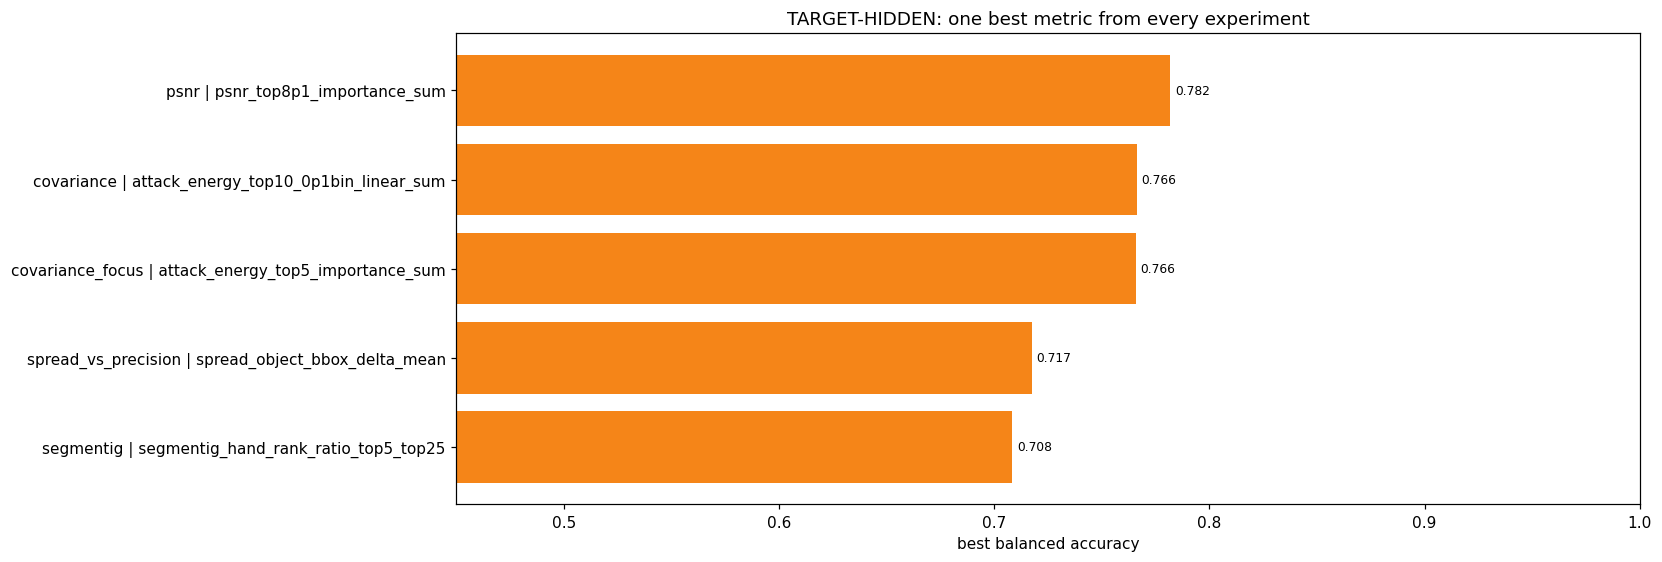

,source,experiment,metric,n,n_success,n_failure,roc_auc,cache_file,legacy_roc_auc,family,top_percent,aggregate,cov_method,sigma,cov_group,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction,effective_auc,label
0,detector_target_instance,psnr,psnr_top8p1_importance_sum,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,sum,NaN,NaN,NaN,0.687719,0.600920,0.803828,114687.157134,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,114687.157134,-1,0.854285,psnr | psnr_top8p1_importance_sum
150,detector_target_instance,covariance,attack_energy_top10_0p1bin_linear_sum,1674,495,1179,0.830425,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.557198,NaN,NaN,NaN,full_ig_32,0.5,low,0.660777,0.587127,0.755556,3089.763132,1,0.770609,0.766243,0.587127,0.755556,0.776930,0.660777,0.770609,3089.763132,1,0.830425,covariance | attack_energy_top10_0p1bin_linear...
152,detector_target_instance,covariance_focus,attack_energy_top5_importance_sum,1674,495,1179,0.830466,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.687814,NaN,NaN,NaN,NaN,NaN,NaN,0.659649,0.582946,0.759596,3319.444855,1,0.768220,0.765718,0.582946,0.759596,0.771841,0.659649,0.768220,3319.444855,1,0.830466,covariance_focus | attack_energy_top5_importan...
232,detector_target_instance,spread_vs_precision,spread_object_bbox_delta_mean,4717,1463,3254,0.764758,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.652607,spread,NaN,NaN,NaN,NaN,NaN,0.612342,0.498497,0.793575,0.461454,1,0.688361,0.717316,0.498497,0.793575,0.641057,0.612342,0.688361,0.461454,1,0.764758,spread_vs_precision | spread_object_bbox_delta...
241,detector_target_instance,segmentig,segmentig_hand_rank_ratio_top5_top25,4717,1463,3254,0.767792,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.669002,NaN,NaN,NaN,NaN,NaN,NaN,0.603158,0.485417,0.796309,0.234103,1,0.675005,0.708388,0.485417,0.796309,0.620467,0.603158,0.675005,0.234103,1,0.767792,segmentig | segmentig_hand_rank_ratio_top5_top25


best per experiment: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_instance_all_metrics/target_instance_best_per_experiment.csv


In [6]:
historical = reevaluate_historical_detector_metrics(
    labels, legacy_quality_path=LEGACY_QUALITY, output_dir=OUTPUT_DIR, force=FORCE_METRIC_REBUILD,
)
quality, regression, coverage = historical['quality'], historical['regression'], historical['coverage']
display(coverage)
ranked = quality.assign(effective_auc=lambda x: np.maximum(x.roc_auc, 1-x.roc_auc)).sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=False).copy()
top = ranked.head(30).copy()
top['label'] = top.experiment.astype(str) + ' | ' + top.metric.astype(str)
fig, axes = plt.subplots(1, 2, figsize=(18, 11), constrained_layout=True)
axes[0].barh(np.arange(len(top)), top.best_balanced_accuracy, color='#4c78a8'); axes[0].set_yticks(np.arange(len(top)), top.label); axes[0].invert_yaxis(); axes[0].set_xlim(.45, 1); axes[0].set_title('TARGET-HIDDEN: overall metric top')
axes[1].scatter(quality.legacy_roc_auc, quality.roc_auc, alpha=.25, s=16); axes[1].plot([0,1],[0,1],'k--'); axes[1].set(xlabel='legacy AUC', ylabel='target AUC', title='Effect of relabeling')
plt.show(); display(top)

best_by_experiment = ranked.drop_duplicates('experiment', keep='first').sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=True).copy()
best_by_experiment['label'] = best_by_experiment.experiment.astype(str) + ' | ' + best_by_experiment.metric.astype(str)
best_by_experiment_path = OUTPUT_DIR / 'target_instance_best_per_experiment.csv'
best_by_experiment.drop(columns='label').to_csv(best_by_experiment_path, index=False)
fig, ax = plt.subplots(figsize=(15, max(5, 0.42 * len(best_by_experiment))), constrained_layout=True)
bars = ax.barh(np.arange(len(best_by_experiment)), best_by_experiment.best_balanced_accuracy, color='#f58518')
ax.set_yticks(np.arange(len(best_by_experiment)), best_by_experiment.label); ax.set_xlim(.45, 1)
ax.set_xlabel('best balanced accuracy'); ax.set_title('TARGET-HIDDEN: one best metric from every experiment')
ax.bar_label(bars, labels=[f'{v:.3f}' for v in best_by_experiment.best_balanced_accuracy], padding=3, fontsize=8)
plt.show(); display(best_by_experiment.sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=False))
print('best per experiment:', best_by_experiment_path)

**Первая фигура.** Общий top почти целиком занят близкими вариантами одного PSNR-sweep с balanced accuracy около `0.782`; это не 30 независимых подтверждений, а множество сильно дублирующихся параметризаций одной метрики. Scatter относительно диагонали показывает, что target-aware relabeling существенно меняет AUC многих исторических признаков, иногда даже меняя полезное направление метрики. Поэтому старые выводы нельзя переносить без переоценки под фиксированную identity-aware цель.

**Вторая фигура.** После ограничения до одного победителя на эксперимент PSNR остаётся первым (`0.782`), covariance-варианты дают около `0.766`, spread — `0.717`, segmentation — `0.708`. Исторические observables действительно разделяют outcomes лучше случайного уровня, но это predictive association: особенно PSNR может отражать общую силу/видимость патча и не локализует внутренний механизм детектора. Разрыв между семьями невелик, а выбор best-варианта на той же выборке делает значения оптимистичными без held-out проверки.

### Candidate routing

,source,experiment,metric,n,roc_auc,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
11,candidate_routing,candidate_routing,patched_tracked_logit,5985,0.134163,0.772408,0.690259,0.876752,-1.506955,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,-1.280435,-1
10,candidate_routing,candidate_routing,patched_tracked_score,5985,0.134163,0.772408,0.690259,0.876752,0.181390,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,0.217476,-1
18,candidate_routing,candidate_routing,tracked_logit_delta,5985,0.143820,0.761578,0.684393,0.858386,-3.758296,-1,0.814202,0.824622,0.684393,0.858386,0.790858,0.761578,0.814202,-3.758296,-1
24,candidate_routing,candidate_routing,patched_winner_score,5954,0.111379,0.776170,0.919973,0.671246,0.294545,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,0.315792,-1
25,candidate_routing,candidate_routing,patched_winner_logit,5954,0.111379,0.776170,0.919973,0.671246,-0.873410,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,-0.773177,-1
30,candidate_routing,candidate_routing,winner_iou_clean,5954,0.140245,0.765678,0.822899,0.715898,0.506106,-1,0.850017,0.818157,0.807860,0.726202,0.910112,0.764858,0.847162,0.515136,-1
17,candidate_routing,candidate_routing,tracked_score_delta,5985,0.145351,0.747640,0.660489,0.861286,-0.671713,-1,0.798997,0.813691,0.657489,0.865636,0.761747,0.747340,0.797661,-0.665013,-1
19,candidate_routing,candidate_routing,tracked_box_iou_clean,5985,0.195309,0.634049,0.584967,0.692122,0.746873,-1,0.723810,0.719971,0.684091,0.581924,0.858018,0.628885,0.762573,0.659341,-1
8,candidate_routing,candidate_routing,clean_target_x2,5985,0.275043,0.590476,0.487268,0.749154,483.149536,-1,0.640769,0.676102,0.549893,0.620590,0.731614,0.583106,0.693233,458.083252,-1
6,candidate_routing,candidate_routing,clean_target_x1,5985,0.644220,0.541959,0.438791,0.708555,149.415726,1,0.585965,0.623928,0.488115,0.555824,0.692033,0.519774,0.644946,180.600052,1


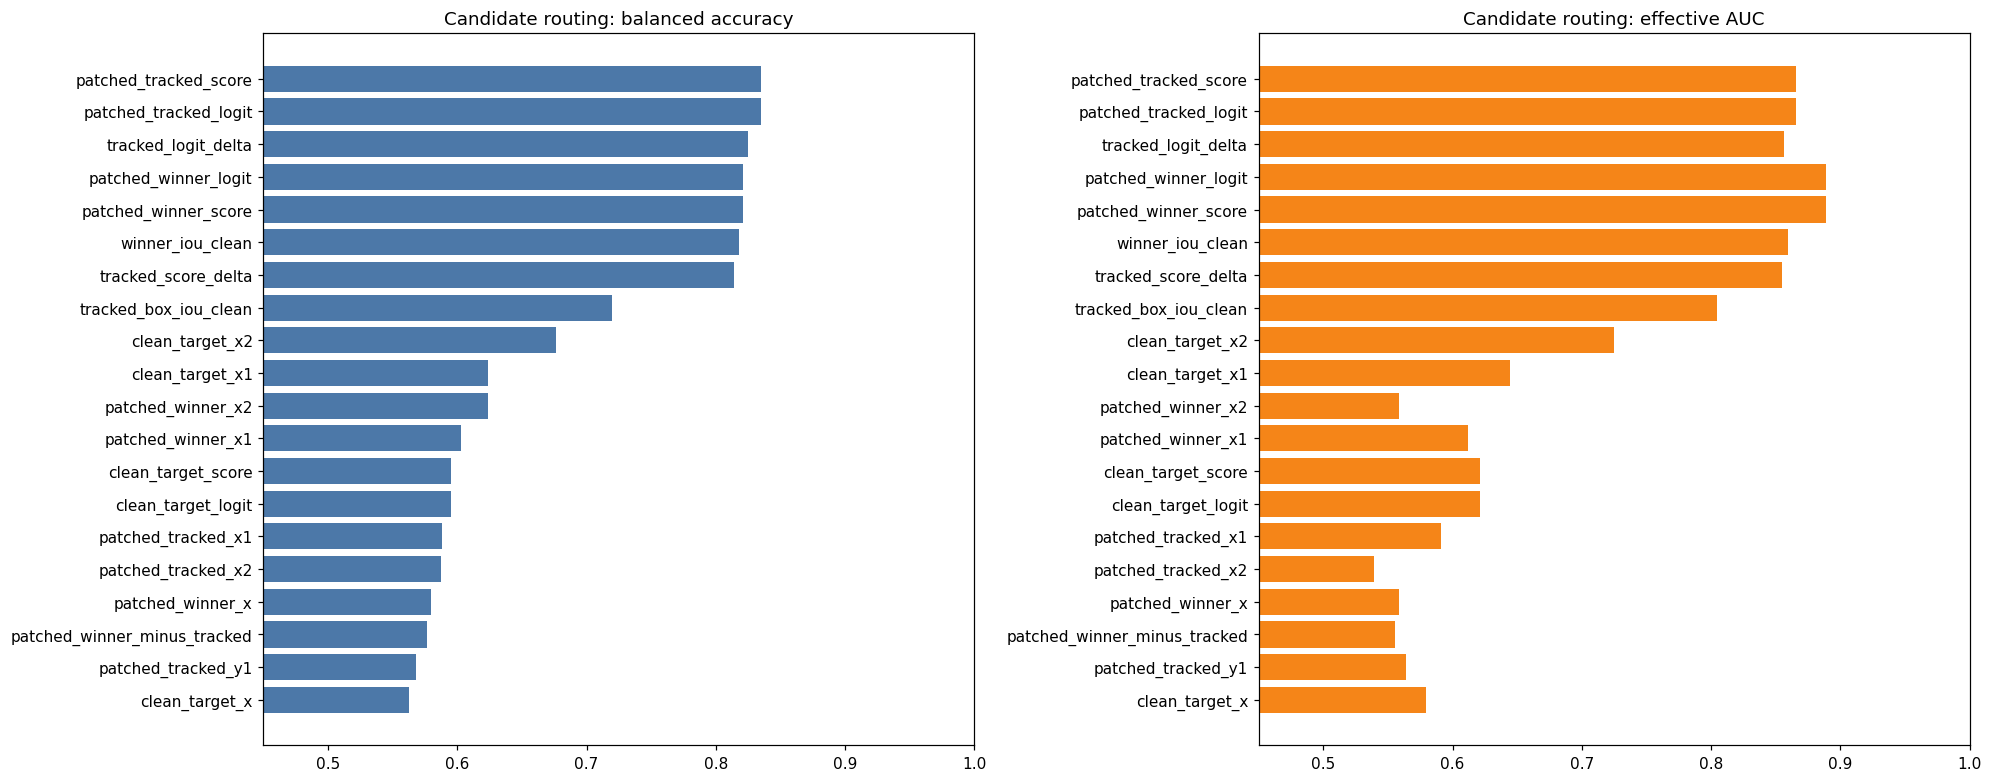

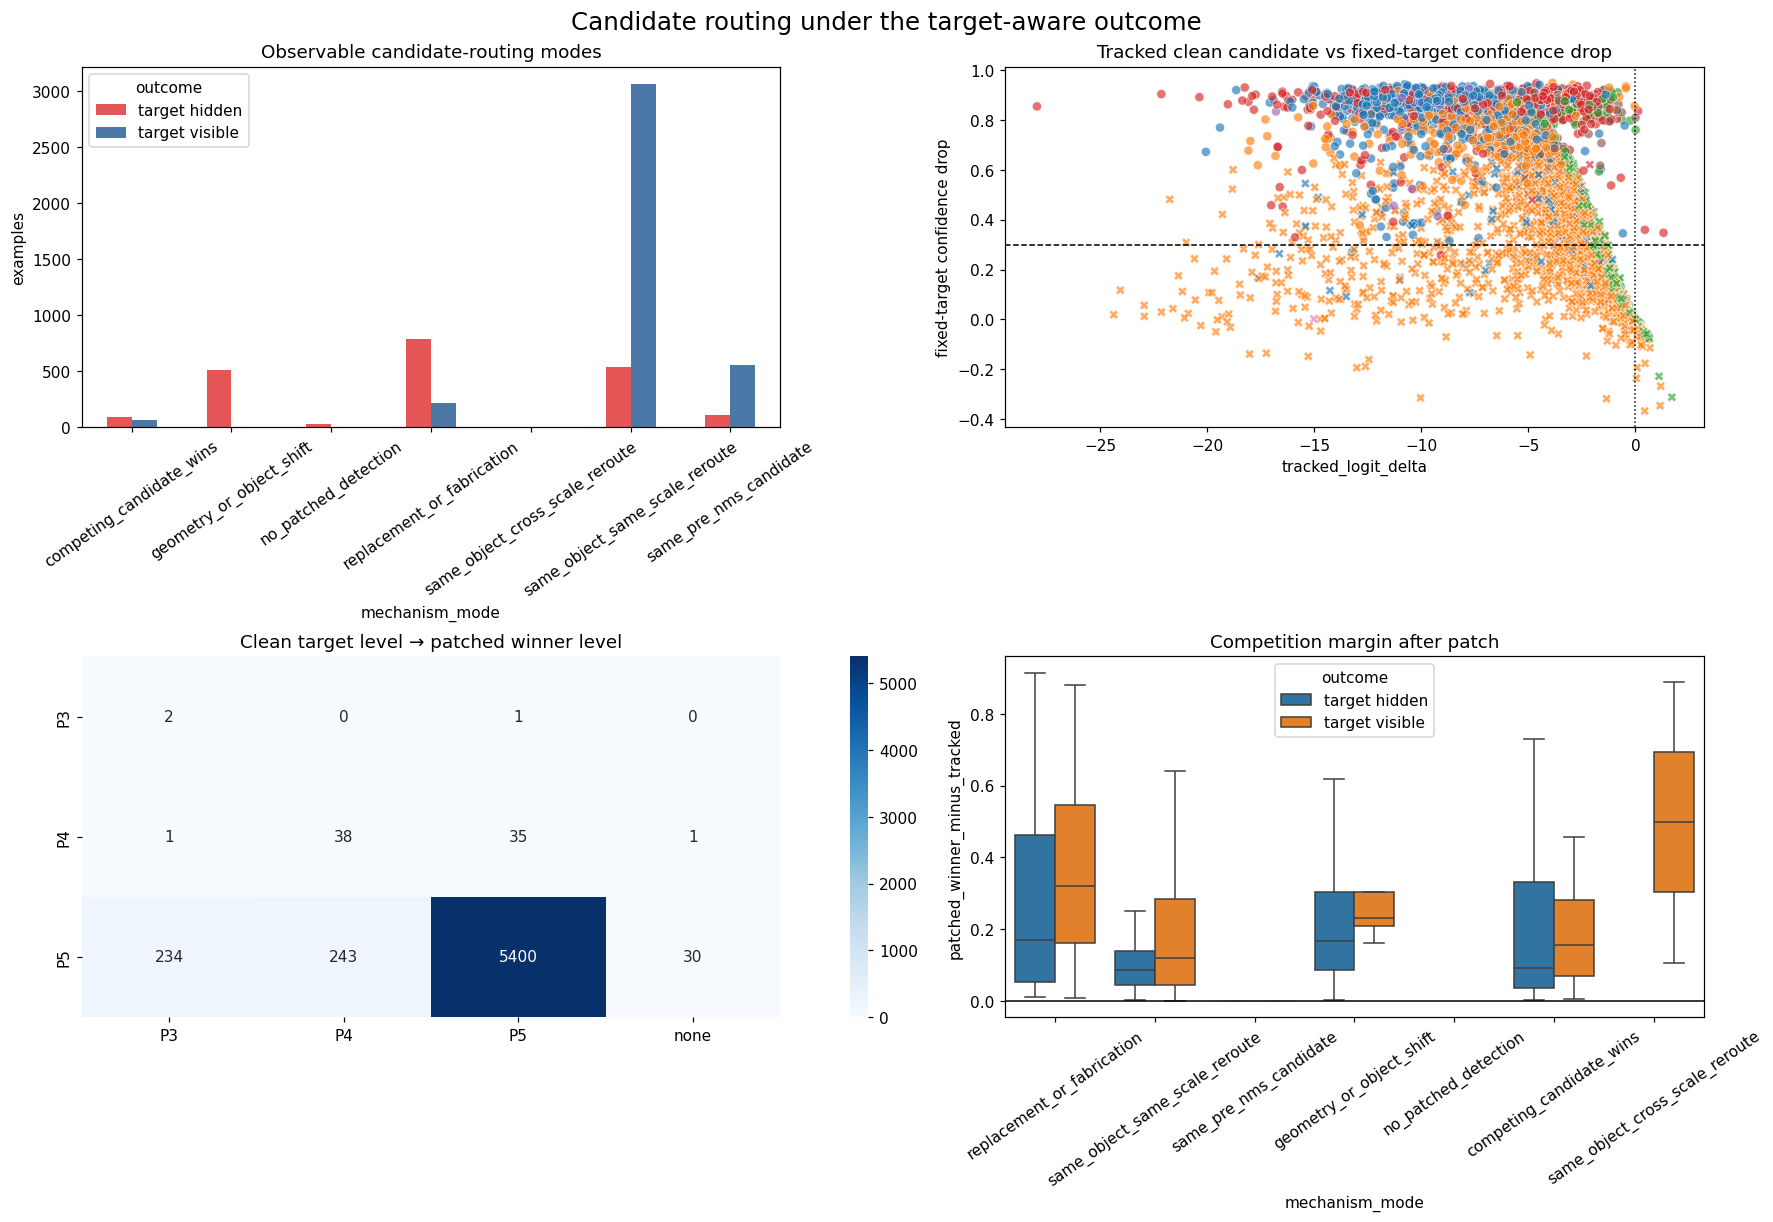

### Combined leaderboard

,source,experiment,metric,n,n_success,n_failure,roc_auc,cache_file,legacy_roc_auc,family,top_percent,aggregate,cov_method,sigma,cov_group,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction,effective_auc
5296,attack_path,attack_path_tracked_clean,positive_contribution,200,NaN,NaN,0.915890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.871287,0.907216,0.838095,6.263947,1,0.870000,0.871679,0.907216,0.838095,0.905263,0.871287,0.870000,6.263947,1,0.915890
5297,attack_path,attack_path_tracked_clean,total_abs_contribution,200,NaN,NaN,0.928321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.880734,0.849558,0.914286,14.289261,1,0.870000,0.868421,0.933333,0.800000,0.936842,0.861538,0.865000,17.581390,1,0.928321
5298,attack_path,attack_path_tracked_clean,negative_contribution,200,NaN,NaN,0.073885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.881818,0.843478,0.923810,-8.319838,-1,0.870000,0.867669,0.849558,0.914286,0.821053,0.880734,0.870000,-8.673065,-1,0.926115
5299,attack_path,attack_path_tracked_clean,score_patched,200,NaN,NaN,0.098847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866667,0.866667,0.866667,-1.075478,-1,0.860000,0.859649,0.866667,0.866667,0.852632,0.866667,0.860000,-1.075478,-1,0.901153
5300,attack_path,attack_path_tracked_clean,path_sum,200,NaN,NaN,0.113083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.840000,0.884211,0.800000,-3.719611,-1,0.840000,0.842607,0.892473,0.790476,0.894737,0.838384,0.840000,-3.775799,-1,0.886917
5301,attack_path,attack_path_tracked_clean,exact_score_delta,200,NaN,NaN,0.113183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.840000,0.884211,0.800000,-3.718022,-1,0.840000,0.842105,0.884211,0.800000,0.884211,0.840000,0.840000,-3.718022,-1,0.886817
5262,candidate_routing,candidate_routing,patched_tracked_logit,5985,NaN,NaN,0.134163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.772408,0.690259,0.876752,-1.506955,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,-1.280435,-1,0.865837
5263,candidate_routing,candidate_routing,patched_tracked_score,5985,NaN,NaN,0.134163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.772408,0.690259,0.876752,0.181390,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,0.217476,-1,0.865837
5264,candidate_routing,candidate_routing,tracked_logit_delta,5985,NaN,NaN,0.143820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.761578,0.684393,0.858386,-3.758296,-1,0.814202,0.824622,0.684393,0.858386,0.790858,0.761578,0.814202,-3.758296,-1,0.856180
5265,candidate_routing,candidate_routing,patched_winner_score,5954,NaN,NaN,0.111379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.776170,0.919973,0.671246,0.294545,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,0.315792,-1,0.888621


compact leaderboard: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_instance_all_metrics/target_instance_combined_quality.csv


: 

In [ ]:
routing_quality = evaluate_candidate_routing_metrics(labels, trace_db=TRACE_DB, output_dir=OUTPUT_DIR)
legacy_path_quality = evaluate_attack_path_metrics(labels, attack_path_db=LEGACY_ATTACK_PATH_DB, output_dir=OUTPUT_DIR)
combined = pd.concat([quality, routing_quality, legacy_path_quality], ignore_index=True, sort=False)
combined['effective_auc'] = np.maximum(combined.roc_auc, 1-combined.roc_auc)
combined = combined.sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=False, na_position='last')
combined_path = OUTPUT_DIR / 'target_instance_combined_quality.csv'
combined.to_csv(combined_path, index=False)
display(Markdown('### Candidate routing')); display(routing_quality.head(30))
routing_top = routing_quality.assign(effective_auc=lambda x: np.maximum(x.roc_auc, 1-x.roc_auc)).sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=True).tail(20).copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
axes[0].barh(routing_top.metric, routing_top.best_balanced_accuracy, color='#4c78a8'); axes[0].set_xlim(.45, 1); axes[0].set_title('Candidate routing: balanced accuracy')
axes[1].barh(routing_top.metric, routing_top.effective_auc, color='#f58518'); axes[1].set_xlim(.45, 1); axes[1].set_title('Candidate routing: effective AUC')
plt.show()

with sqlite3.connect(TRACE_DB) as conn:
    trace_examples = pd.read_sql_query('SELECT * FROM examples WHERE error IS NULL', conn)
trace_examples['image_key'] = trace_examples.path.map(image_key)
trace_target = trace_examples.merge(labels[['image_key', 'target_hidden', 'target_eligible', 'target_conf_drop']], on='image_key', how='inner')
trace_target = trace_target[trace_target.target_eligible.eq(1) & trace_target.target_hidden.notna()].copy()
trace_target['success'] = trace_target.target_hidden.astype(int)
trace_target['confidence_drop'] = trace_target.target_conf_drop
fig = plot_candidate_overview(
    trace_target, outcome_names={0: 'target visible', 1: 'target hidden'},
    confidence_drop_label='fixed-target confidence drop',
)
fig.suptitle('Candidate routing under the target-aware outcome', fontsize=16)
plt.show()
display(Markdown('### Combined leaderboard')); display(combined.head(50))
print('compact leaderboard:', combined_path)

**Первая фигура.** Лучшие routing-признаки — patched score/logit исходной raw candidate-cell, которая породила clean target, их delta и score/logit patched winner — дают balanced accuracy примерно `0.82–0.84` и effective AUC около `0.86–0.89`. Здесь `patched_tracked_score` **не является** `target_patched_conf`, по которому построена success-метка: первый измеряется до NMS строго в исходной clean-ячейке, а второй — после NMS у наиболее уверенного patched-бокса с `IoU >= 0.5` к target. Поэтому соседняя ячейка может подхватить человека после подавления tracked-cell, а её score — не равен outcome по определению. На текущих данных порог `patched_tracked_score < 0.25` ошибается в `1 177 / 5 985` случаях: `1 017` targets остаются видимыми благодаря другому кандидату и `160` оказываются hidden при score исходной ячейки не ниже порога. Напротив, `target_patched_conf < 0.25` дал бы accuracy `1.0`, но это была бы тавтологическая утечка самой метки, а не объясняющая метрика. Routing-признаки всё равно расположены почти у endpoint: они хорошо описывают, *что* случилось с детекцией после патча, но не обязательно объясняют, *почему* это случилось внутри сети.

**Вторая фигура.** У видимых примеров резко доминирует same-object/same-scale reroute, тогда как geometry/object shift и replacement/fabrication непропорционально часто встречаются среди hidden. Матрица уровней показывает, что подавляющее большинство переходов остаётся `P5 → P5` (`5 400` случаев): routing в основном локальный, а не cross-scale. Scatter демонстрирует, что большой отрицательный delta tracked-logit сам по себе не гарантирует hiding — соседний кандидат может сохранить объект. В boxplot видимые outcomes обычно имеют больший competition margin, особенно при reroute; это указывает на candidate redundancy как на возможный компенсатор подавления исходной ячейки.